# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Report Discussion:**  In problem 2, why is the expected result as so? Did you get the expected result in both eigenenergies and ground state wavefunction? why or why not
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Camello, Zack Kenshin)_: 
- _Student No._: 2024-08825
- _Section_: THR-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

# Report figure

## Problem 1
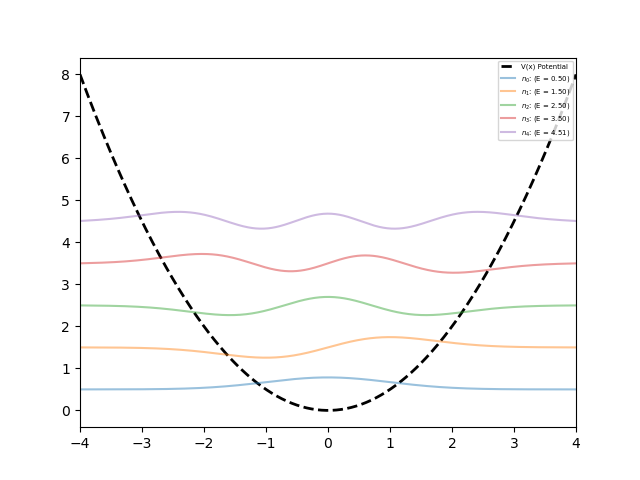

## Problem 2
## a. Theoretical vs Experimental Eigenvalues
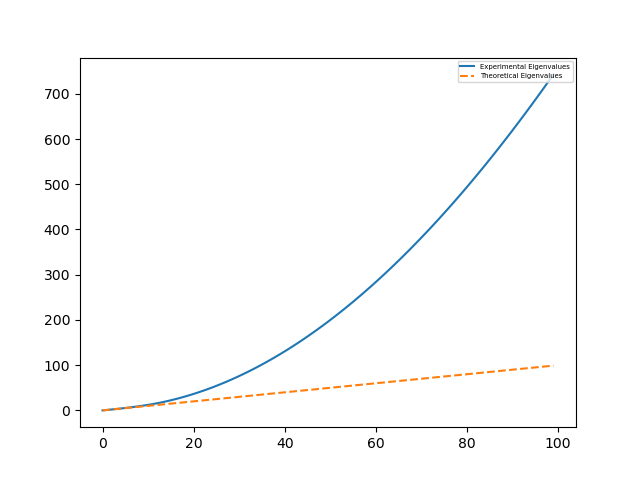

## b. Potential and Probability Density of the Ground State
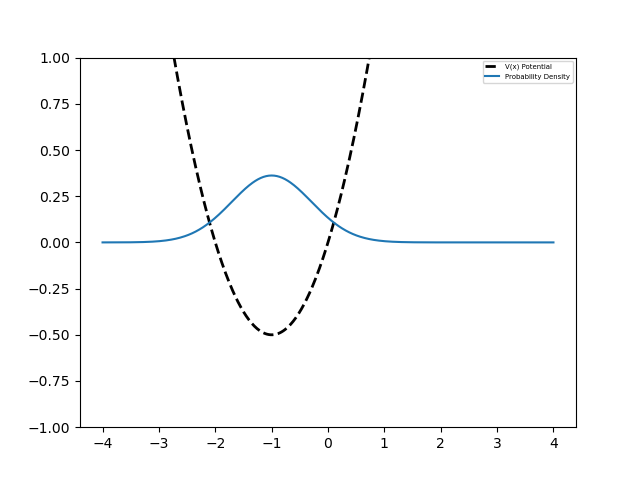

# Report discussion

In problem 2, why is the expected result as so? Did you get the expected result in both eigenenergies and ground state wavefunction? why or why not
- For the Probability Density graph we first look at our Potential function, $V(x) = \frac{1}{2}m\omega^2x^2 + qEx$ which simplifies to $V(x) = \frac{1}{2}x^2 + x$ as $m$, $\omega$, and $qE \implies qq^{-1}$ all equal to $1$. We then factor out the $\frac{1}{2}$ and complete the square of $V(x)$. This gives us $V(x) = \frac{1}{2}[x^2 + 2x + 1 - 1] \implies V(x) = \frac{1}{2}[(x + 1)^2 - 1] \implies \frac{1}{2}(x + 1)^2 - \frac{1}{2}$. From this, we see $x$ gets shifted to the left by $-1$, while our overall $V(x)$ shifts down by $- frac{1}{2}$. These match the values on the graph, in which the probability density peaks at $x = -1$, while the potential starts at $0.5$.
- For our eigenenergies, our experimental vs theoretical values only align at small values of $n$. At higher values, the resulting eigenvalues from our custom formula diverge from the expected theoretical values. This is mainly due to the fact that the simulation is limited from $-4$ to $4$. While low-n wavefunctions stay safely within these limits, higher-n valued wavefunctions (and higher energy) hit these "walls" early and are forced to abruptly drop to 0. This sudden drop causes the wave's slope to become extremely steep, causing the wave to oscillate at extremely high frequencies. Given that the oscillation of a wave corresponds to its momentum, at this point, the momentum spikes and becomes extremely large. As our Kinetic Energy depends on momentum ($\frac{p^2}{2m}$), our Energy spikes at these points as well. This is exactly why at low values of n, our wavefunction behaves as expected, but upon reaching the walls of our simulation, its energy diverges greatly from theory. Even if we were to increase our bounds to accomodate more states, this boundary problem would simply occur much later unless an infinite x axis were implemented. 

# Other comments

---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=\mathscr{E}_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + \mathscr{E}_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=\omega=1$. 

Eigenvalues: 
 [0.4999924  1.49997286 2.50007655 3.50133626 4.50852993] 



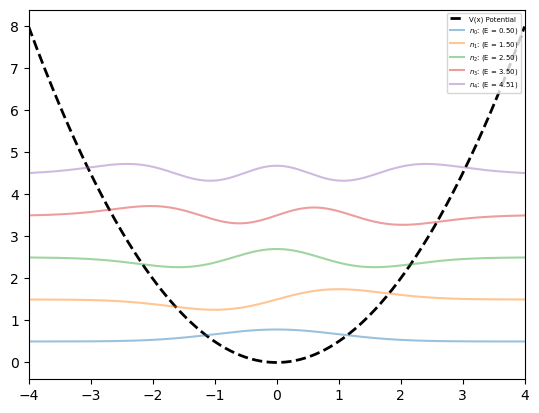

In [1]:
# code here

import numpy as np
import matplotlib.pyplot as plt

N = 500
mass = 1
omega = 1
hbar = 1
x_pos = np.linspace (-4,4, N) # For better visualization changes bounds from -3 to 3 to -4 to 4
dx = x_pos[1] - x_pos[0]

# (a)
# https://www.overleaf.com/read/khcsrksksshr#895fdf

# (b) 
def hamiltonian(x_pos, potential_array, mass):
    
    main_diag = -2 * (np.eye(N)) # Main -2 Diagonal
    upper_diag = np.eye(N, k=1) # Upper 1 Diagonal
    lower_diag = np.eye(N, k=-1) # Lower 1 Diagonal
    coeff = -((hbar**2)/(2 * mass * (dx**2)))
    
    T_matrix = coeff * (main_diag + upper_diag + lower_diag) # Creates the Kinetic matrix
    V_matrix = np.diag(potential_array) # Creates the Potential matrix
 
    Hamiltonian = T_matrix + V_matrix # Calculates the Hamiltonian

    return Hamiltonian

# (c) 
V = (1/2) * mass * (omega**2) * (x_pos**2) # Sets our Potential to look like this

hamiltonian = hamiltonian(x_pos, V, mass) # Calculates Hamiltonian matrix using specified values
eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian) # Calculates Eigenvalues and Eigenvectors of our Hamiltonian matrix
print("Eigenvalues: \n", eigenvalues[:5], "\n")

plt.figure()
plt.plot(x_pos, V, color='black', linewidth=2, label="V(x) Potential", linestyle="--") # Plots the Potential

for n in range(5):
    E_n = eigenvalues[n] # nth eigenvalue
    psi_n = 3*eigenvectors[:, n] # nth eigenvector which is taken from all rows, from the nth column. Given a factor of 3 for visualization purposes
    f_n = psi_n + E_n 
    
    plt.plot(x_pos, f_n, label=f"$n_{n}$: (E = {E_n:.2f})", alpha = 0.45) # Plots the first 5 wavefunctions through this part of the loop

plt.legend(fontsize=5, loc = "upper right")
plt.xlim(-4,4)
plt.savefig("Problem 1 Wavefunction")
plt.show()

#### Problem 1 code summary

The code simply calculates the Hamiltonian and solves for its corresponding Eigenvalues and Eigenvectors and plots them. 

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
\mathscr{E}_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

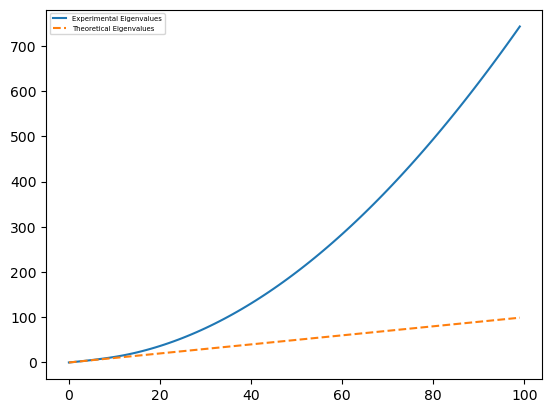

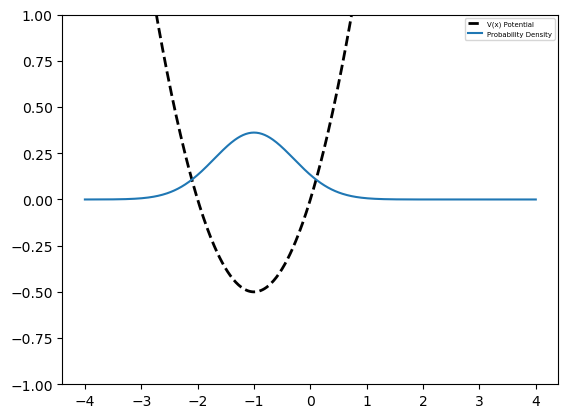

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 500
mass = 1
omega = 1
hbar = 1
x_pos = np.linspace (-4,4, N) # For better visualization changes bounds from -3 to 3 to -4 to 4
dx = x_pos[1] - x_pos[0]

def hamiltonian(x_pos, potential_array, mass):
    
    main_diag = -2 * (np.eye(N)) # Main -2 Diagonal
    upper_diag = np.eye(N, k=1) # Upper 1 Diagonal
    lower_diag = np.eye(N, k=-1) # Lower 1 Diagonal
    coeff = -((hbar**2)/(2 * mass * (dx**2)))
    
    T_matrix = coeff * (main_diag + upper_diag + lower_diag) # Creates the Kinetic matrix
    V_matrix = np.diag(potential_array) # Creates the Potential matrix
 
    Hamiltonian = T_matrix + V_matrix # Calculates the Hamiltonian

    return Hamiltonian

# (a)
V = ((1/2) * mass * (omega**2) * (x_pos**2)) + x_pos # Since E = q^-1 qEx = qq^{-1}x = x

hamiltonian = hamiltonian(x_pos, V, mass) # Calculates Hamiltonian matrix using specified values
eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian) # Calculates Eigenvalues and Eigenvectors of our Hamiltonian matrix

# For Theoretical Values
n_range = np.arange(100) # Gives n = 0, 1, 2 .. 99 
E_theoretical = (hbar * omega * (n_range + (1/2))) - (1/(2 * mass * (omega**2))) # Calculates the theoretical values for every n

plt.figure()
    
plt.plot(n_range, eigenvalues[:100], label="Experimental Eigenvalues")
plt.plot(n_range, E_theoretical, label="Theoretical Eigenvalues", linestyle="--")
plt.legend(fontsize=5, loc = "upper left")
plt.savefig("Problem 2 Wavefunction")
plt.show()

# (b)
psi_0 = eigenvectors[:, 0] # This takes the first eigenvector which corresponds to the ground state
probability = np.abs(psi_0)**2 # Probability density is just the wavefunction squared

plt.figure()

plt.plot(x_pos, V, color='black', linewidth=2, label="V(x) Potential", linestyle="--") # Plots the Potential
plt.plot(x_pos, probability*40, label="Probability Density") 

# Multiplied by 60 for visualization. Relative probability stays the same. If we know a particle was 5x as likely to appear in x1 than x0, when multiplying the entire probability curve by some coefficient, this fact still stays true.

plt.ylim(-1, 1)
plt.legend(fontsize=5, loc = "upper right")
plt.savefig("Problem 2 Probability Density")
plt.show()

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)